In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import sys
import numpy as np
import pandas as pd
import scipy
import scanpy as sc
import liana as li
import logging
import traceback

import multiprocessing


os.chdir('15.Liana_bydonor/')
from Liana_Extra_Plot_Functions import *



OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


FileNotFoundError: [Errno 2] No such file or directory: '15.Liana_bydonor/'

In [2]:
import pkg_resources

# Get a list of all installed packages and their versions
installed_packages = pkg_resources.working_set

# Iterate through the installed packages and print their names and versions
for package in installed_packages:
    print(f"{package.key}=={package.version}")



diff-match-patch==20200713
xarray==2024.1.0
tzdata==2023.4
certifi==2022.12.7
fsspec==2022.11.0
regex==2022.7.9
pytz==2022.7
dask==2022.7.0
distributed==2022.7.0
imagecodecs==2021.8.26
tifffile==2021.7.2
setuptools==65.6.3
cryptography==39.0.1
keyring==23.4.0
conda==23.3.1
pyzmq==23.2.0
pyopenssl==23.0.0
boltons==23.0.0
black==22.6.0
pip==22.3.1
twisted==22.2.0
attrs==22.1.0
packaging==22.0
contextlib2==21.6.0
incremental==21.3.0
argon2-cffi==21.3.0
argon2-cffi-bindings==21.2.0
hyperlink==21.0.0
virtualenv==20.25.0
automat==20.2.0
service-identity==18.1.0
constantly==15.1.0
rich==13.7.0
websockets==12.0
pillow==9.4.0
pyobjc-framework-coreservices==9.0
pyobjc-framework-cocoa==9.0
pyobjc-core==9.0
pyobjc-framework-fsevents==9.0
ipython==8.10.0
natsort==8.4.0
click==8.0.4
tenacity==8.0.1
jupyter-client==7.3.4
pytest==7.1.2
inflect==7.0.0
ipykernel==6.19.2
deepdiff==6.7.1
sip==6.6.2
nbconvert==6.5.4
notebook==6.5.2
pydocstyle==6.3.0
importlib-resources==6.1.1
tornado==6.1
multidict==6.0.4


In [32]:
import hdf5plugin
adata = sc.read_h5ad('results/2024_04_22_Immune_Metacells_combined_stored_counts.h5ad.ztsd')

In [33]:
adata.obs['Clusters'].unique()

['MTC_123', 'MTC_456', 'MTC_Prolif', 'NEUT', 'MONO', 'T Cells', 'B Cells']
Categories (7, object): ['B Cells', 'MONO', 'MTC_123', 'MTC_456', 'MTC_Prolif', 'NEUT', 'T Cells']

In [34]:
# Copying the 'liana_res' data from 'adata.uns' into a new DataFrame 'df'
df = adata.uns["liana_res"].copy()

# Creating a condition to filter the DataFrame based on specific criteria:
# 1. 'specificity_rank' less than or equal to 0.05
# 2. 'magnitude_rank' less than or equal to 0.05
# 3. 'source' column containing values 'MTC_123' or 'MTC_456'
condition = (df['specificity_rank'] <=0.05) & (df['magnitude_rank'] <=0.05) & (df['source'].isin(['MTC_123','MTC_456']))


In [ ]:
# Creating a condition to filter the DataFrame based on specific criteria:
# 1. 'specificity_rank' less than or equal to 0.05
# 2. 'magnitude_rank' less than or equal to 0.05
# 3. 'target' column containing values 'MTC_123' or 'MTC_456'
condition = (df['specificity_rank'] <=0.05) & (df['magnitude_rank'] <=0.05) & (df['target'].isin(['MTC_123','MTC_456']))

# Filtering the DataFrame based on the defined condition
filtered_df = df[condition]

# Creating a new column 'CCI' by concatenating values from other columns
filtered_df['CCI'] = filtered_df['source'].astype(str)+':' + filtered_df['ligand_complex'].astype(str) + '.' + filtered_df['receptor_complex'].astype(str)

# Selecting specific columns to keep in the filtered DataFrame
columns_to_keep = ['CCI', 'target','lr_means']
subset_filtered_df = filtered_df[columns_to_keep]

# Pivot the dataframe to have sources as columns
pivot_df = subset_filtered_df.pivot(index='CCI', columns='target', values='lr_means')

# Fill missing values with 0
pivot_df.fillna(0, inplace=True)

# Calculate log2FC
pivot_df['log2FC'] = np.log2(pivot_df['MTC_456'] + 1) - np.log2(pivot_df['MTC_123'] + 1)

# If you want non-existing values as zero, replace NaN values with 0
pivot_df['log2FC'].fillna(0, inplace=True)

# Reset index to make CCI a column again
pivot_df.reset_index(inplace=True)

# Print the result
print(pivot_df)

# Filter rows with absolute log2FC > 2
filtered_pivot_df= pivot_df[abs(pivot_df['log2FC']) > 1.5]

# Define a function to determine the cluster based on log2FC
def determine_cluster(row):
    if row['log2FC'] > 0:
        return 'MTC_456'
    elif row['log2FC'] < 0:
        return 'MTC_123'
    else:
        return None

# Apply the function to create the 'cluster' column
filtered_pivot_df['cluster'] = filtered_pivot_df.apply(determine_cluster, axis=1)

# Sort the dataframe by the 'log2FC' column
filtered_pivot_df = filtered_pivot_df.sort_values(by='log2FC')

# Reset the index
filtered_pivot_df.reset_index(drop=True, inplace=True)


# Print the filtered dataframe
print(filtered_pivot_df)
filtered_pivot_df.to_csv('results/2024_03_28_Log2FC_CCIs_Targets_MTC123_vs_MTC456.csv')

In [36]:
os.chdir('15.Liana_bydonor/')
from Liana_Extra_Plot_Functions import *

In [37]:
adata.uns["liana_res"]

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,lr_probs,cellchat_pvals,specificity_rank,magnitude_rank
5453,MTC_456,NEUT,SPP1,CD44,3.893356,0.0,10.963501,1.541408,2.922254,0.071002,0.963017,0.254660,0.0,0.014529,4.732851e-11
4543,MTC_456,MONO,SPP1,CD44,3.851905,0.0,10.470951,1.480778,3.085206,0.067812,0.962190,0.240754,0.0,0.014529,1.277595e-09
7020,MTC_Prolif,NEUT,SPP1,CD44,3.238347,0.0,8.546183,1.223176,1.090093,0.055347,0.958317,0.210081,0.0,0.014529,3.573573e-08
2079,MONO,MTC_456,TIMP1,CD63,3.226183,0.0,10.210638,1.057699,2.301782,0.059812,0.961729,0.241517,0.0,0.014529,4.462969e-08
1657,MONO,MONO,TIMP1,CD63,3.177637,0.0,9.854238,1.020223,1.972345,0.057724,0.961070,0.235805,0.0,0.014529,7.988922e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8681,NEUT,T Cells,FAM3C,CLEC2D,0.550664,0.0,0.148263,0.709033,0.893010,0.040969,0.751747,0.000000,1.0,0.175529,1.000000e+00
8682,NEUT,T Cells,FAM3C,LAMP1,0.388410,1.0,0.097314,-0.223918,-0.302461,0.010106,0.710420,0.000000,1.0,1.000000,1.000000e+00
8683,NEUT,T Cells,FN1,CD44,0.627839,0.0,0.241114,0.800345,1.307460,0.038175,0.794308,0.000000,1.0,0.191153,1.000000e+00
8748,NEUT,T Cells,LGALS9,SLC1A5,0.478034,1.0,0.136978,-0.162075,-0.361115,0.011542,0.744286,0.000000,1.0,1.000000,1.000000e+00


In [ ]:
from __future__ import annotations
import os
import sys
import numpy as np
import pandas as pd
import scipy
import scanpy as sc
import liana as li
import logging
import traceback
from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean

import multiprocessing
import numpy as np
import anndata
import pandas
import pandas as pd 
import plotnine as p9

from plotnine import ggplot, geom_point, aes, \
    facet_grid, labs, theme_bw, theme, element_text, element_rect, scale_size_continuous, scale_color_cmap

from liana.plotting._common import _prep_liana_res, _check_var, _get_top_n, _filter_by, _inverse_scores

from liana._docs import d
from liana._constants import Keys as K, DefaultValues as V

def _filter_by2(liana_res, filter_fun):
    if filter_fun is not None:
        msk = liana_res.apply(filter_fun, axis=1).astype(bool)
        relevant_interactions = np.unique(liana_res[msk].interaction)
        liana_res = liana_res[np.isin(liana_res['interaction'], relevant_interactions)]

    return liana_res


@d.dedent
def dotplot4(adata: anndata.AnnData = None,
            uns_key = K.uns_key,
            liana_res: pandas.DataFrame = None,
            colour: str = None,
            size: str = None,
            source_labels: list = None,
            target_labels: list = None,
            top_n: int = None,
            orderby: str | None = None,
            orderby_ascending: bool | None = None,
            orderby_absolute: bool = False,
            filter_fun: callable = None,
            ligand_complex: str | None = None,
            receptor_complex: str | None = None,
            inverse_colour: bool = False,
            inverse_size: bool = False,
            cmap: str = V.cmap,
            size_range: tuple = (2, 9),
            figure_size: tuple = (8, 6),
            return_fig=V.return_fig
            ) -> ggplot:
    """
    Dotplot interactions by source and target cells

    Parameters
    ----------
    %(adata)s
    %(uns_key)s
    %(liana_res)s
    %(colour)s
    %(size)s
    %(source_labels)s
    %(target_labels)s
    %(top_n)s
    %(orderby)s
    %(orderby_ascending)s
    %(orderby_absolute)s
    %(filter_fun)s
    %(ligand_complex)s
    %(receptor_complex)s
    %(inverse_colour)s
    %(inverse_size)s
    %(cmap)s
    %(size_range)s
    %(figure_size)s

    Returns
    -------
    A `plotnine.ggplot` instance

    """
    liana_res = _prep_liana_res(adata=adata,
                                liana_res=liana_res,
                                source_labels=source_labels,
                                target_labels=target_labels,
                                ligand_complex = ligand_complex,
                                receptor_complex = receptor_complex,
                                uns_key=uns_key
                                )
    
    color_var = colour
    size_var= size
    _check_var(liana_res, var=colour, var_name='colour')
    _check_var(liana_res, var=size, var_name='size')

    liana_res = _filter_by2(liana_res, filter_fun)
    liana_res = _get_top_n(liana_res, top_n, orderby, orderby_ascending, orderby_absolute)

    # inverse sc if needed
    if inverse_colour:
        liana_res[colour] = _inverse_scores(liana_res[colour])
    if inverse_size:
        liana_res[size] = _inverse_scores(liana_res[size])

    print(liana_res[size])
    print(liana_res[colour])
    # generate plot
    # generate plot
    p = (ggplot(liana_res, aes(x='target', y='interaction', colour=color_var, size=size_var))
         + geom_point()
         + facet_grid('~source')
         + scale_size_continuous(range=size_range,minor_breaks=1)
         + scale_color_cmap(cmap)
         + labs(
                #color=str.capitalize(colour),
                #size=[None if x == 0 else x for x in size],
                y="Interactions (Ligand -> Receptor)",
                x="Target",
                title="Source")
         + theme_bw()
         + theme(legend_text=element_text(size=14),
                 strip_background=element_rect(fill="white"),
                 strip_text=element_text(size=15, colour="black"),
                 axis_text_y=element_text(size=10, colour="black"),
                 axis_title_y=element_text(colour="#808080", face="bold", size=15),
                 axis_text_x=element_text(size=11, face="bold", angle=90),
                 figure_size=figure_size,
                 plot_title=element_text(vjust=0, hjust=0.5, face="bold",
                                         colour="#808080", size=15)
                 )
         )
    
    if return_fig:
        return p

    p.draw()







In [ ]:
adata.obsp

/opt/homebrew/anaconda3/lib/python3.10/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 8 x 9 in image.
/opt/homebrew/anaconda3/lib/python3.10/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: /Users/dimitrioskyriakis/Documents/Projects/ICH_project/Figures/Figure3_B.pdf


target                      CCI   MTC_123   MTC_456    log2FC  cluster  \
0         MTC_Prolif:APOE.SORL1  3.030703  0.000000 -2.011031  MTC_123   
1            MTC_456:APOE.SORL1  2.970016  0.000000 -1.989145  MTC_123   
2              NEUT:S100A9.TLR4  2.539697  0.000000 -1.823626  MTC_123   
3           MTC_123:HSPA1A.TLR4  2.519387  0.000000 -1.815324  MTC_123   
4                NEUT:COPA.CD74  2.445202  0.000000 -1.784589  MTC_123   
5          MTC_Prolif:C1QB.LRP1  2.426475  0.000000 -1.776725  MTC_123   
6             MONO:LGALS1.PTPRC  2.410801  0.000000 -1.770111  MTC_123   
7            MTC_123:APOE.SORL1  2.309834  0.000000 -1.726759  MTC_123   
8              NEUT:S100A8.TLR4  2.307010  0.000000 -1.725527  MTC_123   
9           B Cells:HLA-DRA.CD4  2.241298  0.000000 -1.696572  MTC_123   
10         MTC_Prolif:APOE.LRP1  2.234624  0.000000 -1.693598  MTC_123   
11       MTC_Prolif:HLA-DRA.CD4  2.213022  0.000000 -1.683931  MTC_123   
12             MONO:S100A9.TLR4  2.201

Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
/opt/homebrew/anaconda3/lib/python3.10/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 8 x 9 in image.
/opt/homebrew/anaconda3/lib/python3.10/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: /Users/dimitrioskyriakis/Documents/Projects/ICH_project/Figures/Figure3_B.png
Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


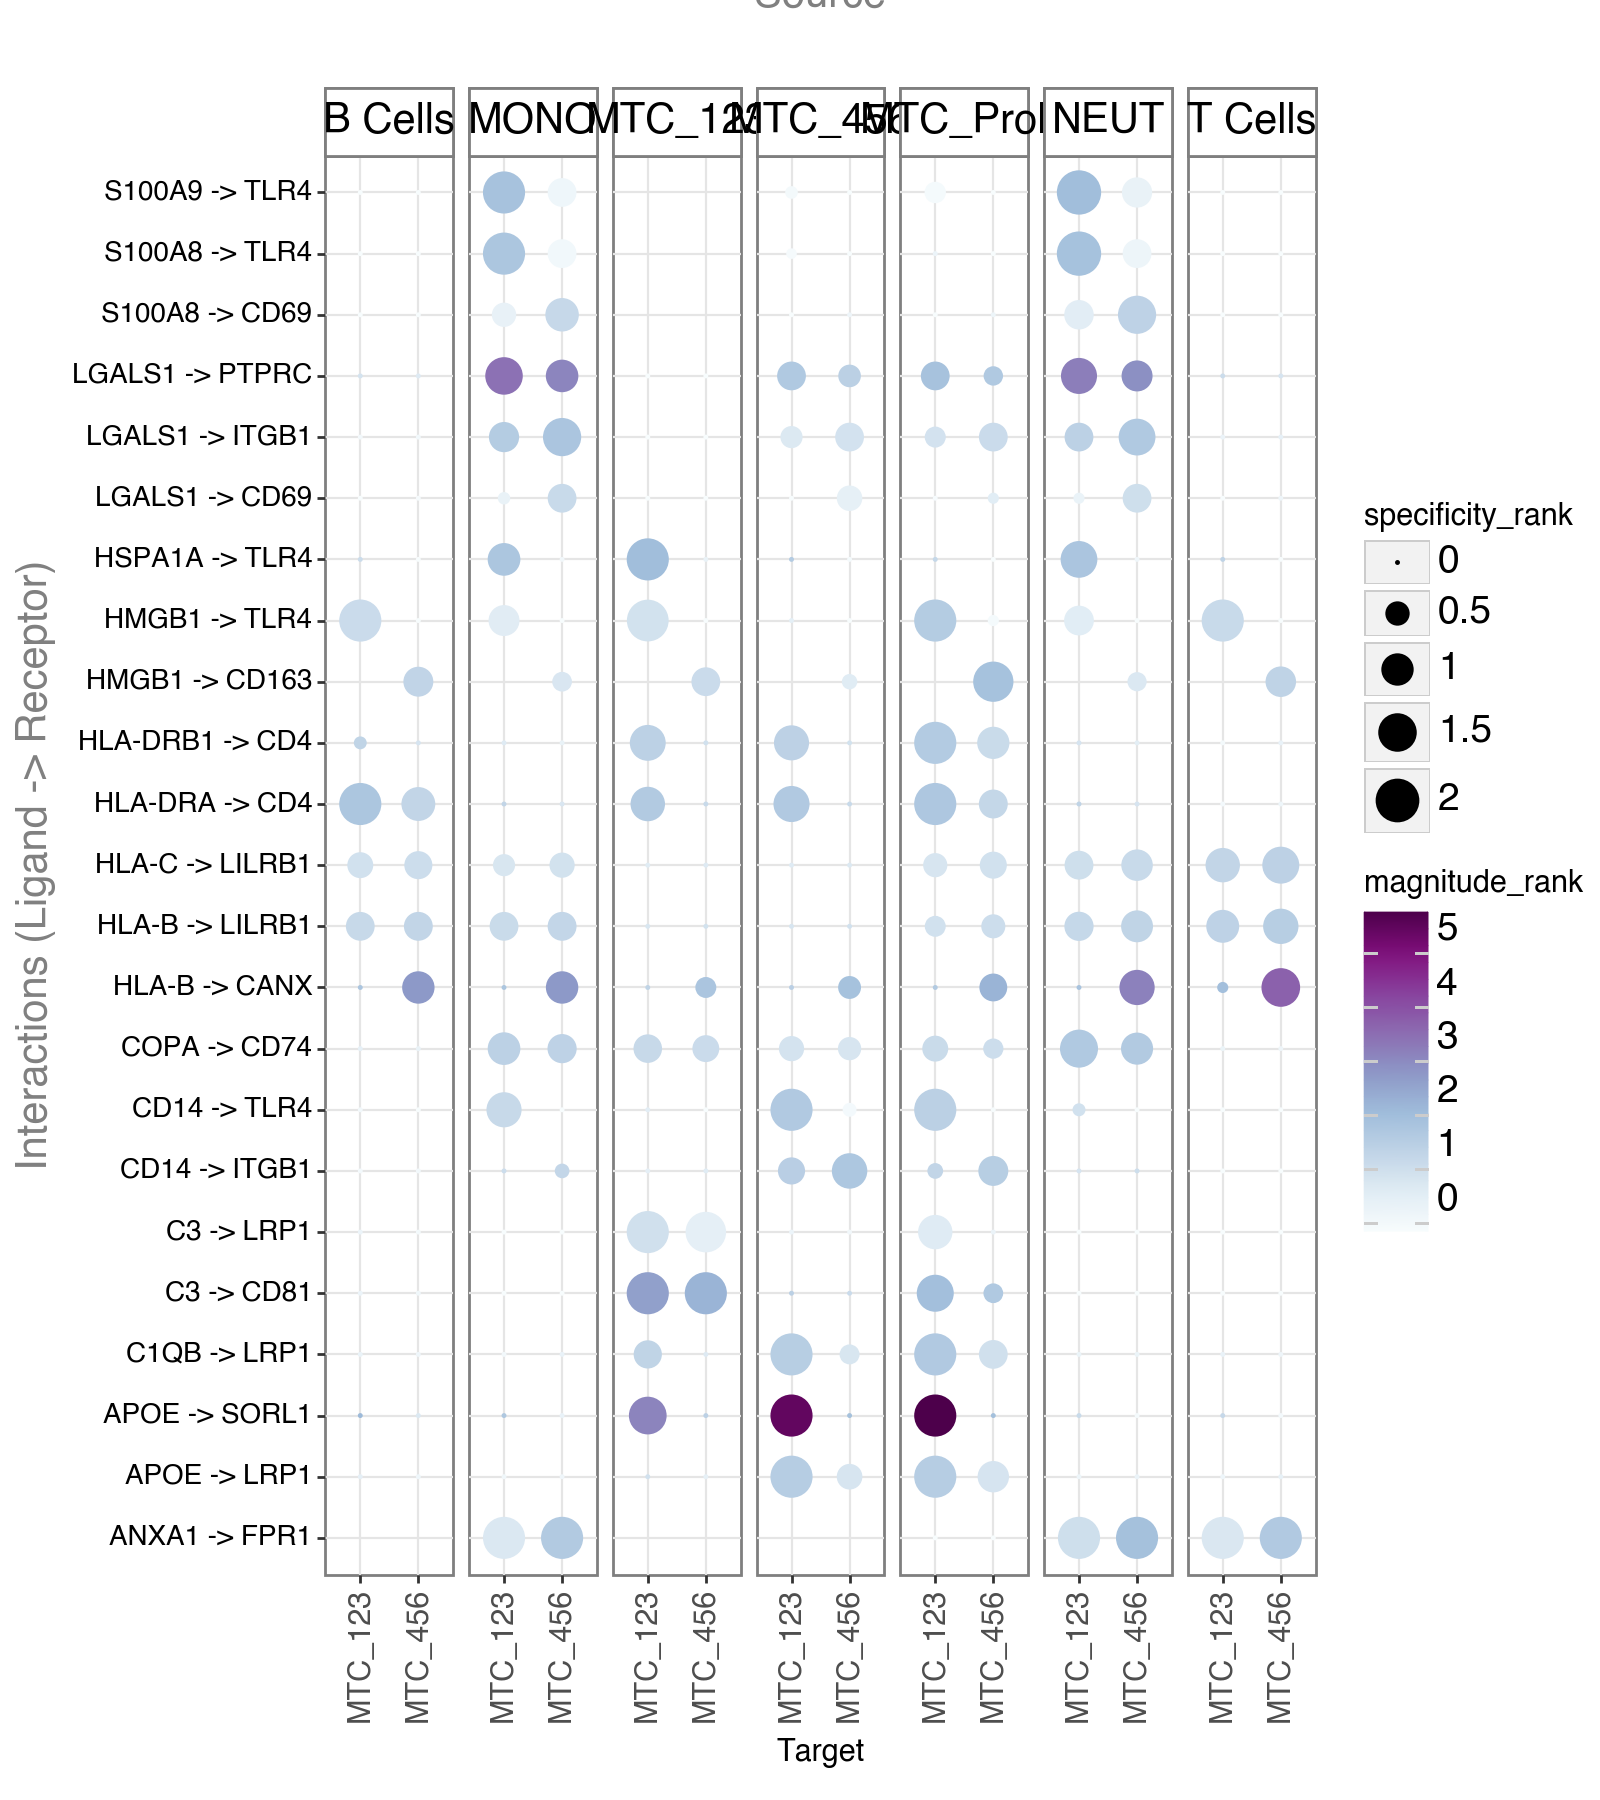

<Figure Size: (800 x 900)>

In [40]:
import pandas as pd

# Sample DataFrame

# Splitting the 'CCI' column into 'Target' and 'Ligand' columns based on the colon delimiter
filtered_pivot_df[['Target', 'Ligand']] = filtered_pivot_df['CCI'].str.split(':', expand=True)

# Extracting the 'Receptor' information from the 'Ligand' column
filtered_pivot_df['Receptor'] = filtered_pivot_df['Ligand'].str.split('.').str[1]

# Extracting the 'Ligand' information from the 'Ligand' column
filtered_pivot_df['Ligand'] = filtered_pivot_df['Ligand'].str.split('.').str[0]

# Printing the resulting DataFrame
print(filtered_pivot_df)

# Extracting significant ligands based on the absolute log2FC threshold of 1.5
Sign_Ligands_Targets = filtered_pivot_df[abs(filtered_pivot_df['log2FC']) > 1.5]['Ligand'].tolist()

# Extracting significant receptors based on the absolute log2FC threshold of 1.5
Sign_Receptors_Targets = filtered_pivot_df[abs(filtered_pivot_df['log2FC']) > 1.5]['Receptor'].tolist()

target_plot = dotplot4(adata = adata,
        colour='magnitude_rank',
        size='specificity_rank',
        target_labels=['MTC_123', 'MTC_456'],
        inverse_size=True,
        filter_fun=lambda x: x['ligand_complex'] in Sign_Ligands_Targets  and x['receptor_complex'] in Sign_Receptors_Targets,
        inverse_colour=True,
        orderby='magnitude_rank',
        orderby_ascending=True,
        figure_size=(8, 9),
        size_range= (0,8),
        cmap = 'BuPu'
    )

target_plot.save('Figures/Figure3_B.pdf') 
target_plot.save('Figures/Figure3_B.png',dpi=300)

target_plot

In [ ]:
condition = (df['specificity_rank'] <=0.05) & (df['magnitude_rank'] <=0.05) & (df['source'].isin(['MTC_123','MTC_456']))
filtered_df = df[condition]
filtered_df['CCI'] = filtered_df['target'].astype(str)+':' + filtered_df['ligand_complex'].astype(str) + '.' + filtered_df['receptor_complex'].astype(str)
columns_to_keep = ['CCI', 'source','lr_means']
subset_filtered_df = filtered_df[columns_to_keep]

# Pivot the dataframe to have sources as columns
pivot_df = subset_filtered_df.pivot(index='CCI', columns='source', values='lr_means')


# Fill missing values with 0
pivot_df.fillna(0, inplace=True)

# Calculate log2FC
pivot_df['log2FC'] = np.log2(pivot_df['MTC_456'] + 1) - np.log2(pivot_df['MTC_123'] + 1)

# If you want non-existing values as zero, replace NaN values with 0
pivot_df['log2FC'].fillna(0, inplace=True)

# Reset index to make CCI a column again
pivot_df.reset_index(inplace=True)

# Print the result
print(pivot_df)

# Filter rows with absolute log2FC > 2
filtered_pivot_df= pivot_df[abs(pivot_df['log2FC']) > 1.5]

# Define a function to determine the cluster based on log2FC
def determine_cluster(row):
    if row['log2FC'] > 0:
        return 'MTC_456'
    elif row['log2FC'] < 0:
        return 'MTC_123'
    else:
        return None

# Apply the function to create the 'cluster' column
filtered_pivot_df['cluster'] = filtered_pivot_df.apply(determine_cluster, axis=1)

# Sort the dataframe by the 'log2FC' column
filtered_pivot_df = filtered_pivot_df.sort_values(by='log2FC')

# Reset the index
filtered_pivot_df.reset_index(drop=True, inplace=True)


# Print the filtered dataframe
print(filtered_pivot_df)

filtered_pivot_df.to_csv('results/2024_04_22_Log2FC_CCIs_Senders_MTC123_vs_MTC456.csv')

In [42]:
import pandas as pd

# Sample DataFrame

# Splitting the values and creating new columns
filtered_pivot_df[['Target', 'Ligand']] = filtered_pivot_df['CCI'].str.split(':', expand=True)
filtered_pivot_df['Receptor'] = filtered_pivot_df['Ligand'].str.split('.').str[1]
filtered_pivot_df['Ligand'] = filtered_pivot_df['Ligand'].str.split('.').str[0]

# print(filtered_pivot_df)

Sign_Ligands_Senders = filtered_pivot_df[abs(filtered_pivot_df['log2FC']) > 1.5]['Ligand'].tolist()
Sign_Receptors_Senders = filtered_pivot_df[abs(filtered_pivot_df['log2FC']) > 1.5]['Receptor'].tolist()

/opt/homebrew/anaconda3/lib/python3.10/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 8 x 9 in image.
/opt/homebrew/anaconda3/lib/python3.10/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: /Users/dimitrioskyriakis/Documents/Projects/ICH_project/Figures/Figure3_B2.pdf
Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


5453    1.837756e+00
4543    1.837756e+00
4599    1.837756e+00
4799    1.837756e+00
5013    1.837756e+00
            ...     
2879   -9.643275e-17
2909   -9.643275e-17
2880   -9.643275e-17
3142   -9.643275e-17
3089   -9.643275e-17
Name: specificity_rank, Length: 266, dtype: float64
5453    1.032488e+01
4543    8.893607e+00
4599    5.312278e+00
4799    5.183037e+00
5013    4.957746e+00
            ...     
2879   -9.643275e-17
2909   -9.643275e-17
2880   -9.643275e-17
3142   -9.643275e-17
3089   -9.643275e-17
Name: magnitude_rank, Length: 266, dtype: float64


/opt/homebrew/anaconda3/lib/python3.10/site-packages/plotnine/ggplot.py:587: PlotnineWarning: Saving 8 x 9 in image.
/opt/homebrew/anaconda3/lib/python3.10/site-packages/plotnine/ggplot.py:588: PlotnineWarning: Filename: /Users/dimitrioskyriakis/Documents/Projects/ICH_project/Figures/Figure3_B2.png
Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


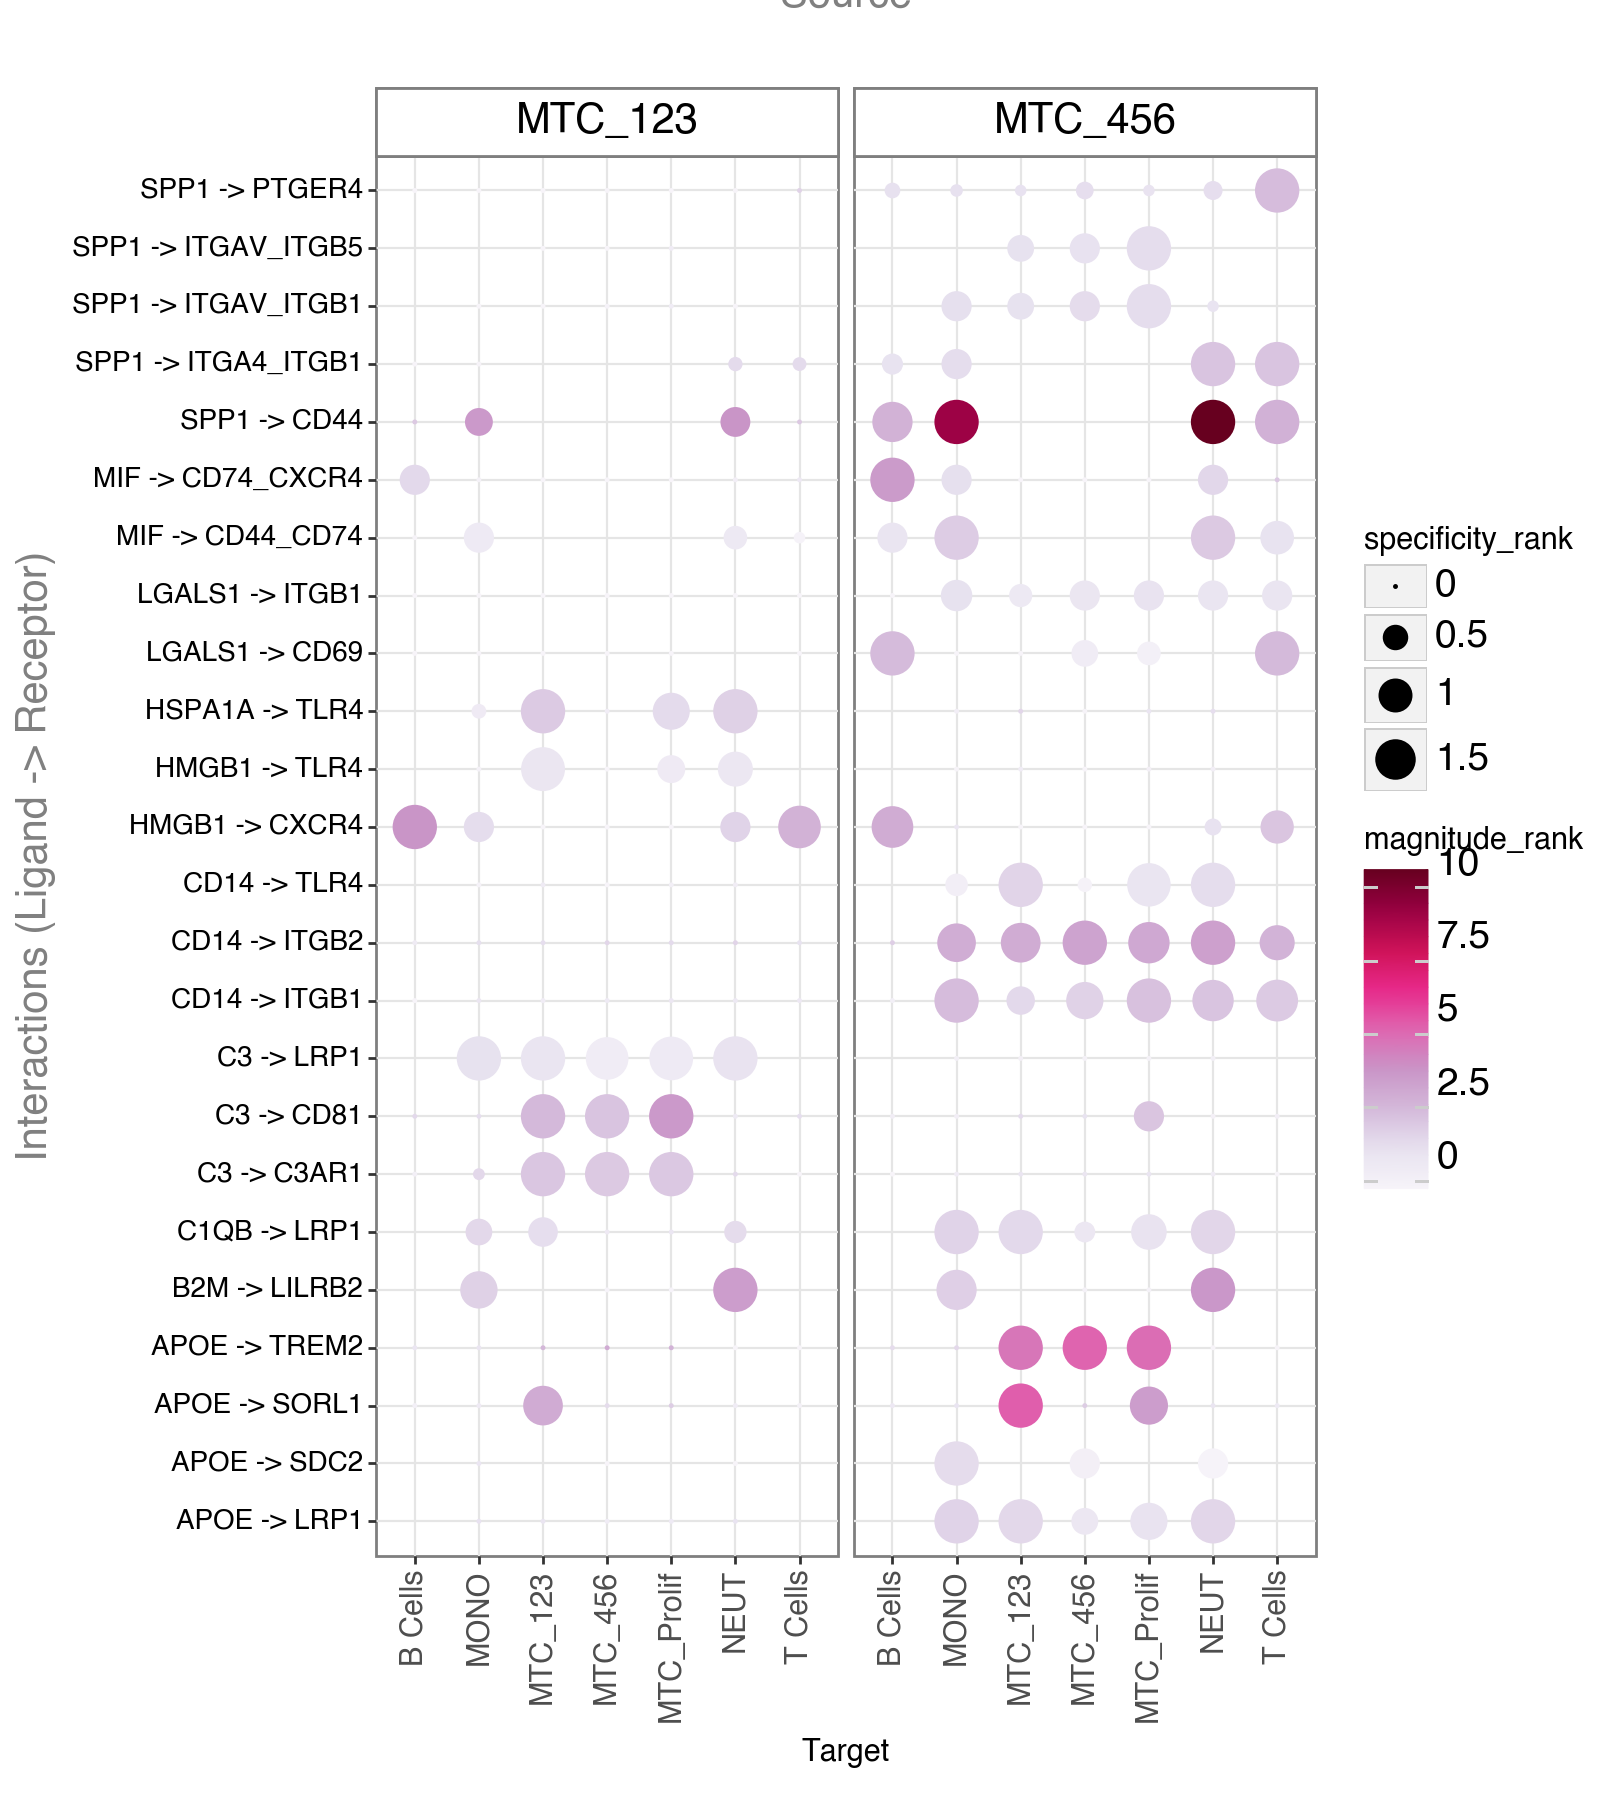

<Figure Size: (800 x 900)>

In [48]:
source_plot = dotplot4(adata = adata,
              colour='magnitude_rank',
              size='specificity_rank',
              source_labels=['MTC_123', 'MTC_456'],
              inverse_size=True,
              filter_fun=lambda x: x['ligand_complex'] in Sign_Ligands_Senders  and x['receptor_complex'] in Sign_Receptors_Senders,
              inverse_colour=True,
              orderby='magnitude_rank',
              orderby_ascending=True,
              figure_size=(8, 9),
              size_range= (0, 8),
              cmap = 'PuRd'
             )


# source_plot.save('results/2024_04_22_CCI_source_plot.pdf')
# source_plot.save('results/2024_04_22_CCI_source_plot.png',dpi=300)

source_plot.save('/Users/dimitrioskyriakis/Documents/Projects/ICH_project/Figures/Figure3_B2.pdf') 
source_plot.save('/Users/dimitrioskyriakis/Documents/Projects/ICH_project/Figures/Figure3_B2.png',dpi=300)

source_plot

4570    1.565356e+01
4949    1.565356e+01
4953    1.565356e+01
3516    1.565356e+01
3518    1.565356e+01
            ...     
3735   -9.643275e-17
4586   -9.643275e-17
5597   -9.643275e-17
5594   -9.643275e-17
5468   -9.643275e-17
Name: cellphone_pvals, Length: 909, dtype: float64
4570    3.226183
4949    3.142297
4953    3.123625
3516    3.095468
3518    3.095468
          ...   
3735    0.315495
4586    0.313224
5597    0.289067
5594    0.281217
5468    0.276128
Name: lr_means, Length: 909, dtype: float32


Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


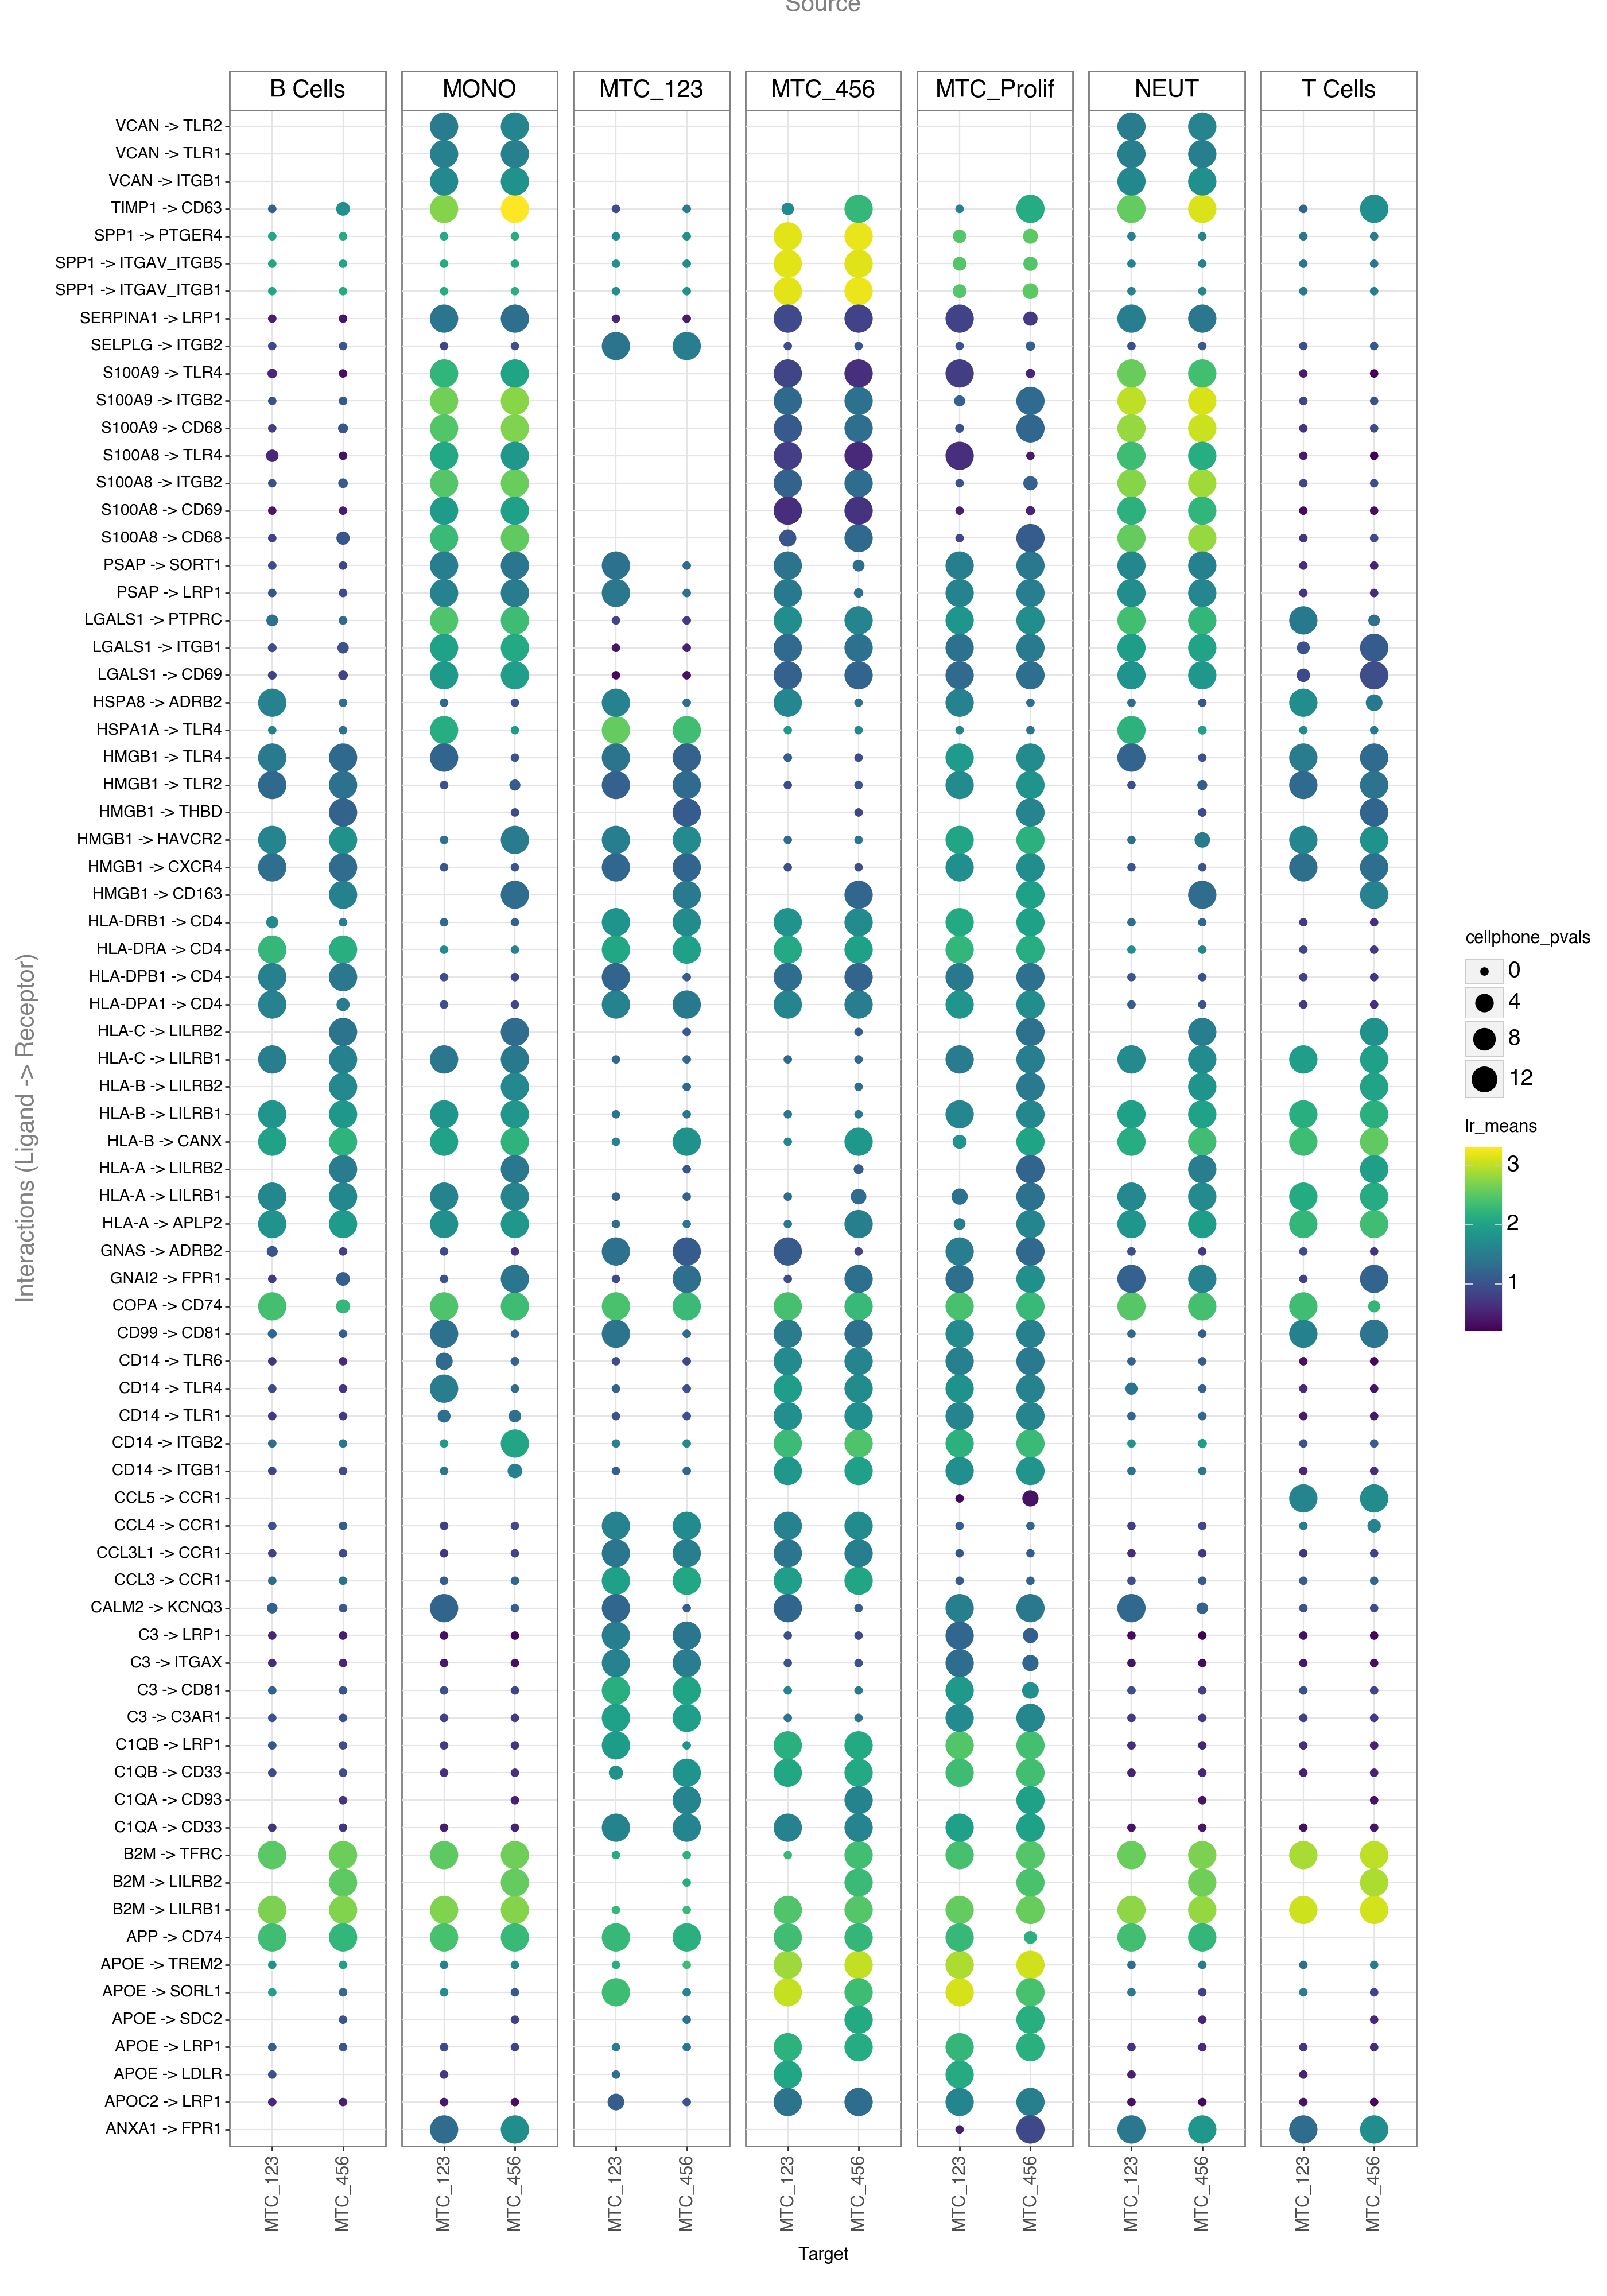

<Figure Size: (1400 x 2000)>

In [46]:
import numpy as np
dotplot4(adata = adata,
               colour='lr_means',
              size='cellphone_pvals',
              inverse_size=True,
              source_labels=['MTC_123', 'MTC_456', 'MTC_Prolif', 'NEUT', 'MONO', 'T Cells', 'B Cells'],
              target_labels=['MTC_123', 'MTC_456'],
            #   inverse_colour=True,
            #   top_n=15,
              filter_fun=lambda x: x['cellphone_pvals'] <= 0.05 and x['lr_means'] >= 1.5,
              uns_key='cpdb_res', # uns_key to use, default is 'liana_res'
              figure_size=(14, 20)
             )

In [126]:
 adata.uns["liana_res"]

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,lr_probs,cellchat_pvals,specificity_rank,magnitude_rank
5453,MTC_456,NEUT,SPP1,CD44,3.893356,0.0,10.963501,1.541408,2.922254,0.071002,0.963017,0.254660,0.0,0.014529,4.732851e-11
4543,MTC_456,MONO,SPP1,CD44,3.851905,0.0,10.470951,1.480778,3.085206,0.067812,0.962190,0.240754,0.0,0.014529,1.277595e-09
7020,MTC_Prolif,NEUT,SPP1,CD44,3.238347,0.0,8.546183,1.223176,1.090093,0.055347,0.958317,0.210081,0.0,0.014529,3.573573e-08
2079,MONO,MTC_456,TIMP1,CD63,3.226183,0.0,10.210638,1.057699,2.301782,0.059812,0.961729,0.241517,0.0,0.014529,4.462969e-08
1657,MONO,MONO,TIMP1,CD63,3.177637,0.0,9.854238,1.020223,1.972345,0.057724,0.961070,0.235805,0.0,0.014529,7.988922e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8681,NEUT,T Cells,FAM3C,CLEC2D,0.550664,0.0,0.148263,0.709033,0.893010,0.040969,0.751747,0.000000,1.0,0.175529,1.000000e+00
8682,NEUT,T Cells,FAM3C,LAMP1,0.388410,1.0,0.097314,-0.223918,-0.302461,0.010106,0.710420,0.000000,1.0,1.000000,1.000000e+00
8683,NEUT,T Cells,FN1,CD44,0.627839,0.0,0.241114,0.800345,1.307460,0.038175,0.794308,0.000000,1.0,0.191153,1.000000e+00
8748,NEUT,T Cells,LGALS9,SLC1A5,0.478034,1.0,0.136978,-0.162075,-0.361115,0.011542,0.744286,0.000000,1.0,1.000000,1.000000e+00


5453    1.837756e+00
4543    1.837756e+00
7020    1.837756e+00
2079    1.837756e+00
1657    1.837756e+00
            ...     
2003   -9.643275e-17
2011   -9.643275e-17
7304   -9.643275e-17
7302   -9.643275e-17
7301   -9.643275e-17
Name: specificity_rank, Length: 2788, dtype: float64
5453    1.032488e+01
4543    8.893607e+00
7020    7.446897e+00
2079    7.350376e+00
1657    7.097512e+00
            ...     
2003   -9.643275e-17
2011   -9.643275e-17
7304   -9.643275e-17
7302   -9.643275e-17
7301   -9.643275e-17
Name: magnitude_rank, Length: 2788, dtype: float64


Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


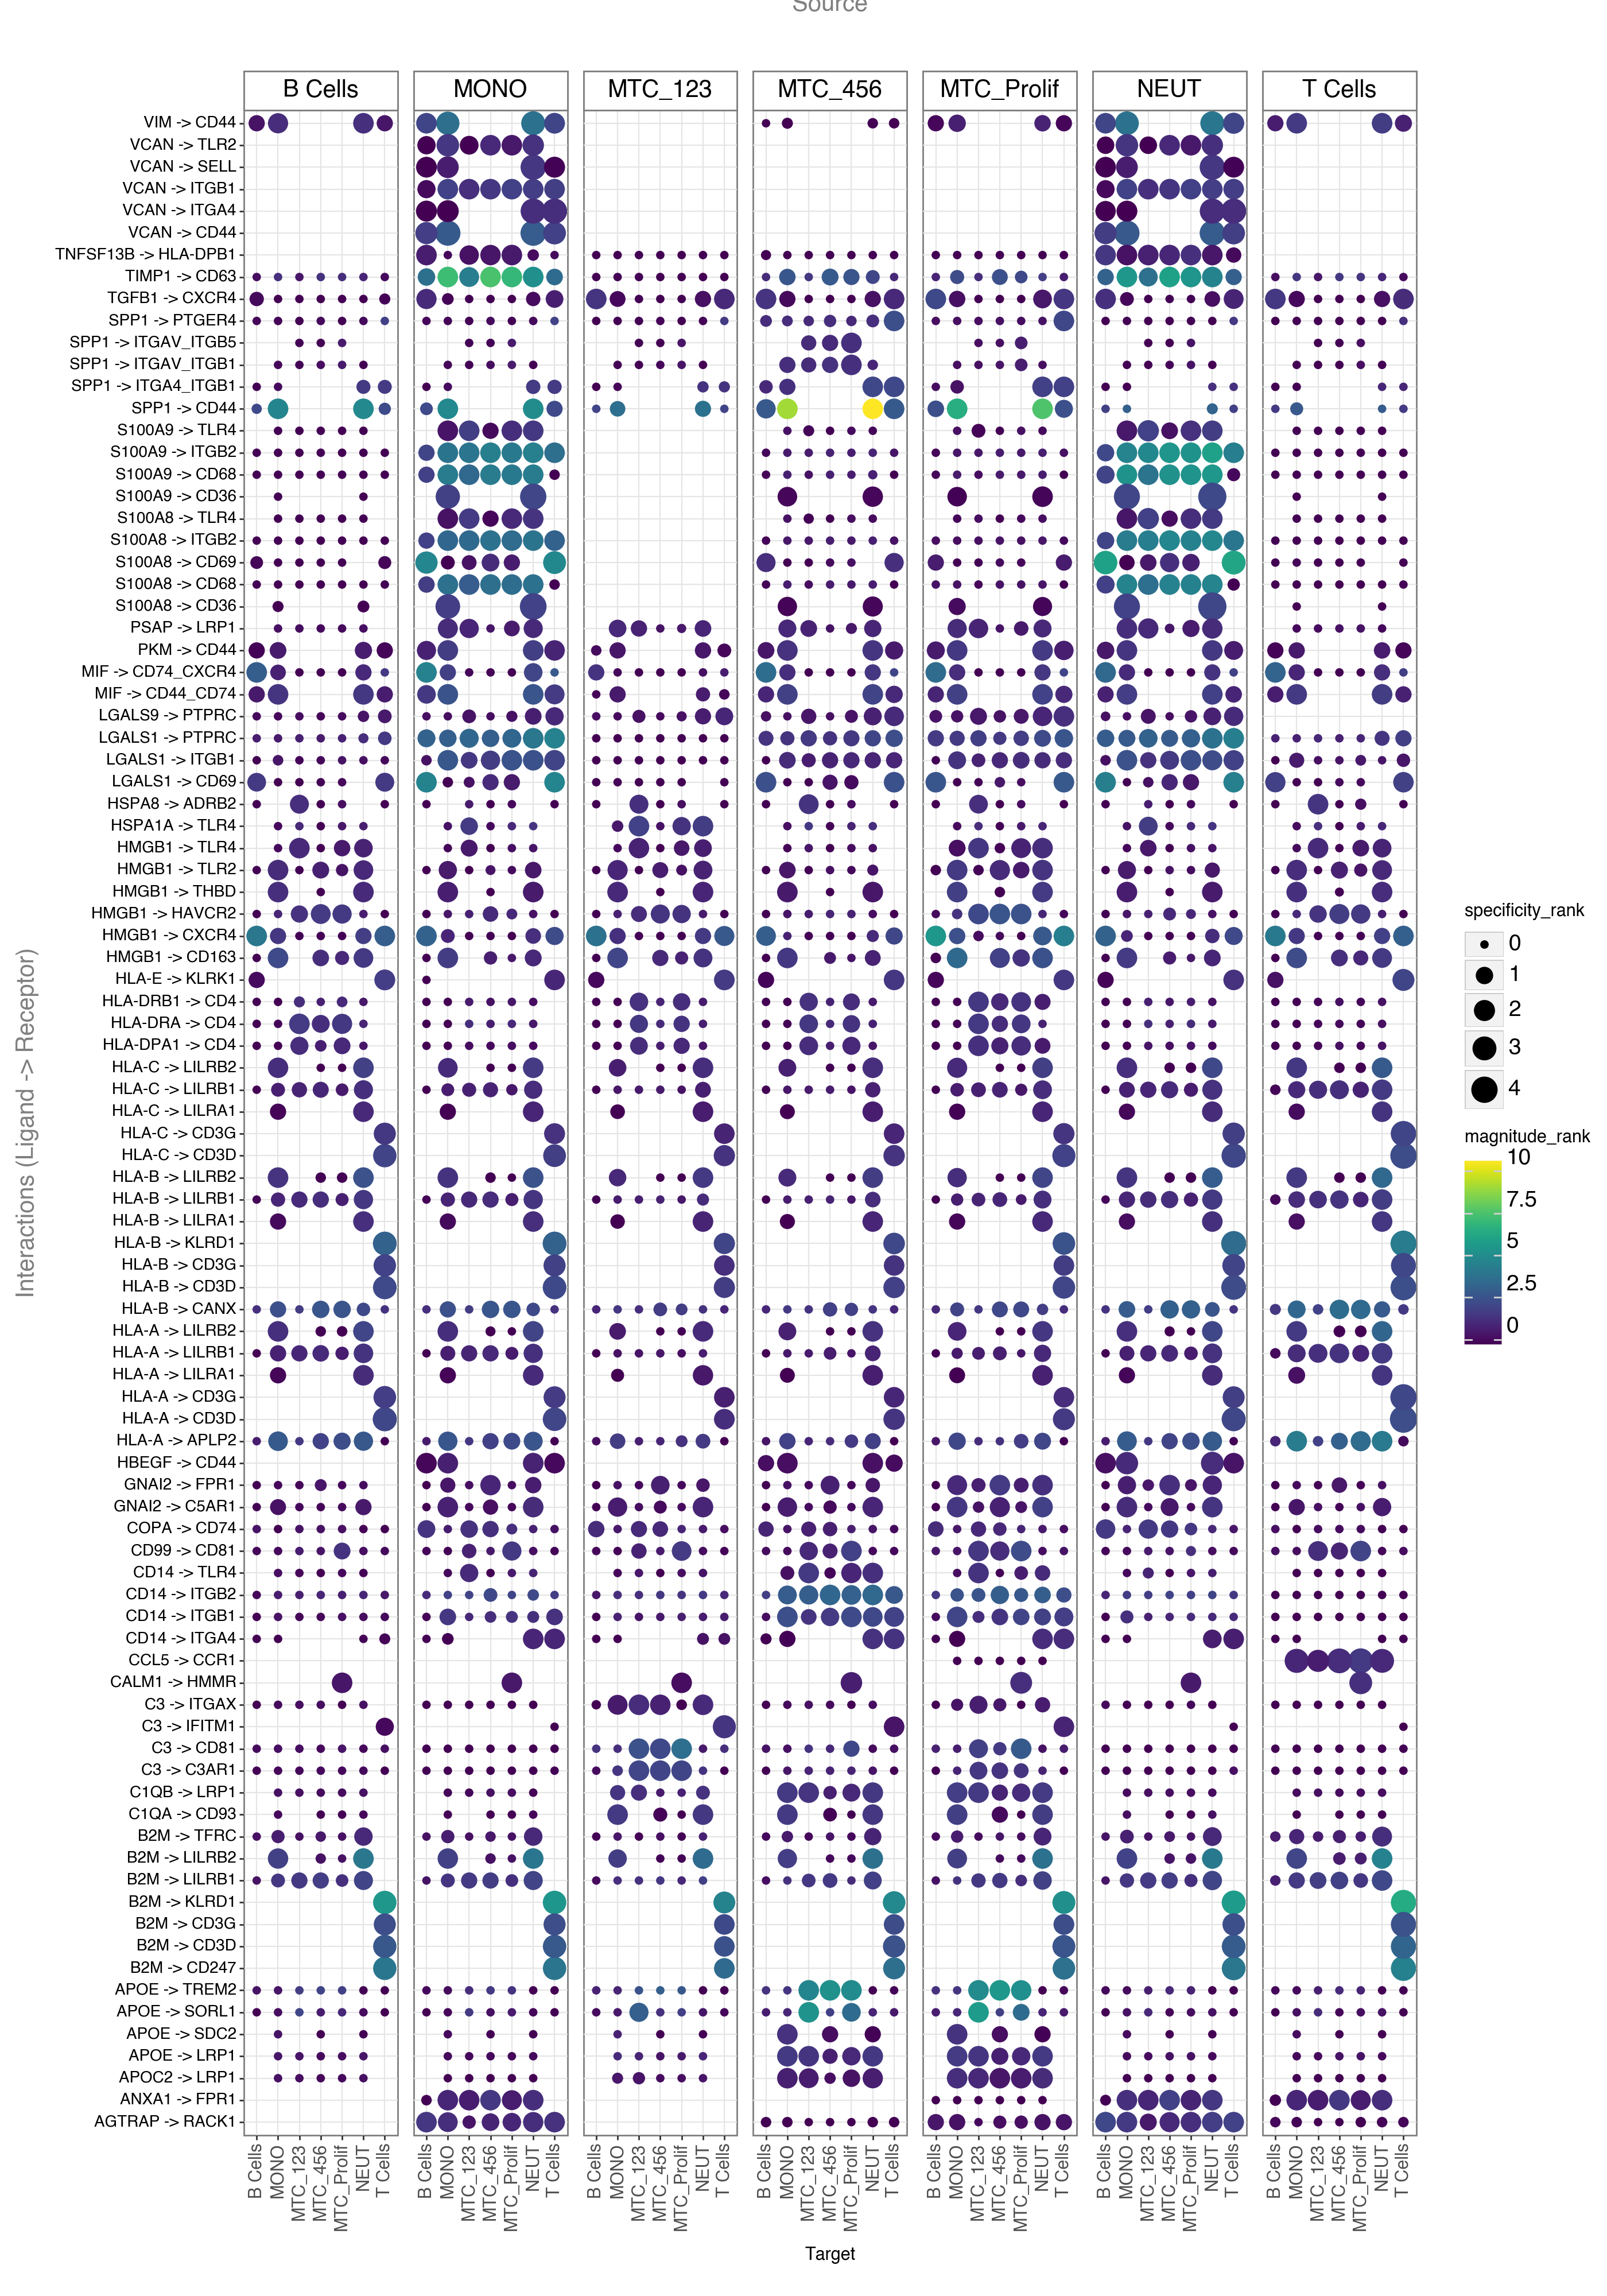

<Figure Size: (1400 x 2000)>

In [47]:
dotplot4(adata = adata,
              colour='magnitude_rank',
              size='specificity_rank',
              inverse_size=True,
            #   source_labels=['MTC_123', 'MTC_456', 'MTC_7', 'MTC_Prolif', 'NEUT', 'MONO', 'T Cells', 'B Cells'],
            #   target_labels=['MTC_123', 'MTC_456'],
              filter_fun=lambda x: x['specificity_rank'] <= 0.05 and x['magnitude_rank'] <= 0.05,
              inverse_colour=True,
            #   top_n=30,
              orderby='magnitude_rank',
              orderby_ascending=True,
              figure_size=(14, 20)
             )